In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr

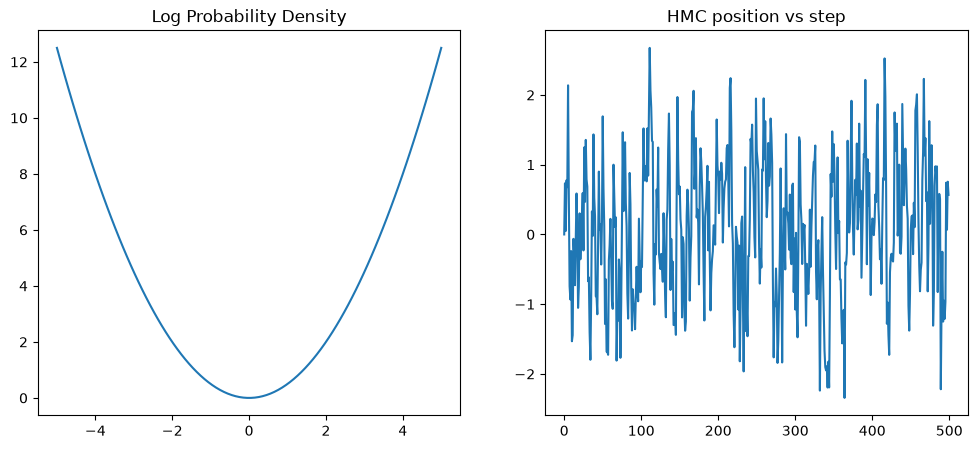

In [40]:
rng = jr.key(24)

inv_mass_matrix = 1
mass_matrix = 1/inv_mass_matrix
mean = 0
sigma = 1

def logdensity (x):
    return 0.5*((x - mean)/(sigma))**2

def logdensity_grad(x):
    return (x - mean)/(sigma**2)

def one_leapfrog_step(position, momentum, dt):
    momentum = momentum - 0.5*dt*logdensity_grad(position)
    position = position + dt*momentum*inv_mass_matrix
    momentum = momentum - 0.5*dt*logdensity_grad(position)
    return position, momentum

def one_overall_step(position, momentum):
    global rng
    position_arr = np.array([position])
    momentum_arr = np.array([momentum])
    rng, key = jr.split(rng)
    momentum = jax.random.normal(key, shape=(1,))*jnp.sqrt(mass_matrix)
    for i in range (1, num_integration_steps):
        position, momentum = one_leapfrog_step(position, momentum, step_size)
    position_arr = np.append(position_arr, position)
    momentum_arr = np.append(momentum_arr, momentum)
    return position, momentum



num_integration_steps = 10
step_size = 1e-1
num_overall_steps = 500
initial_position = 0

position = initial_position
momentum = 0
overall_position_arr = np.array([position])
overall_momentum_arr = np.array([momentum])
for i in range(1, num_overall_steps):
    position, momentum = one_overall_step(position, momentum)
    overall_position_arr = np.append(overall_position_arr, position)
    overall_momentum_arr = np.append(overall_momentum_arr, momentum)



fig, axes = plt.subplots(1, 2, figsize=(12, 5))
density_space = jnp.linspace(-5, 5, 100)
trial_space = jnp.arange(num_overall_steps)
axes[0].plot(density_space, logdensity(density_space))
axes[0].set_title("Log Probability Density")
axes[1].plot(trial_space, overall_position_arr[trial_space])
axes[1].set_title("HMC position vs step")
plt.show()

